In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/spotify_cleaned.csv')
print(df.shape)

(113999, 20)


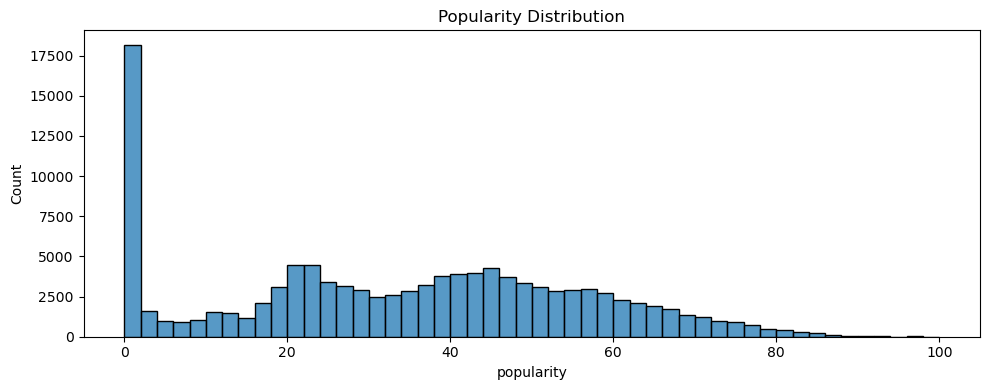

In [2]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='popularity', bins=50)
plt.title('Popularity Distribution')
plt.tight_layout()
plt.show()

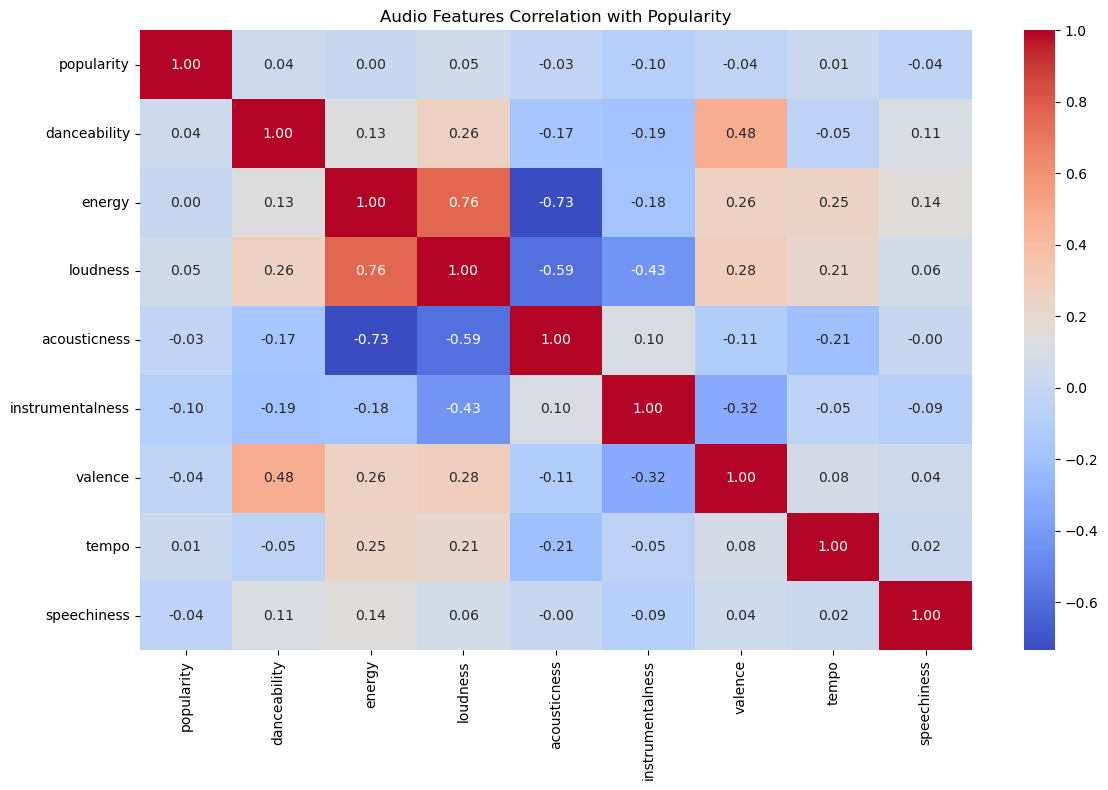

In [3]:
plt.figure(figsize=(12, 8))
features = ['popularity', 'danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'speechiness']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Audio Features Correlation with Popularity')
plt.tight_layout()
plt.show()

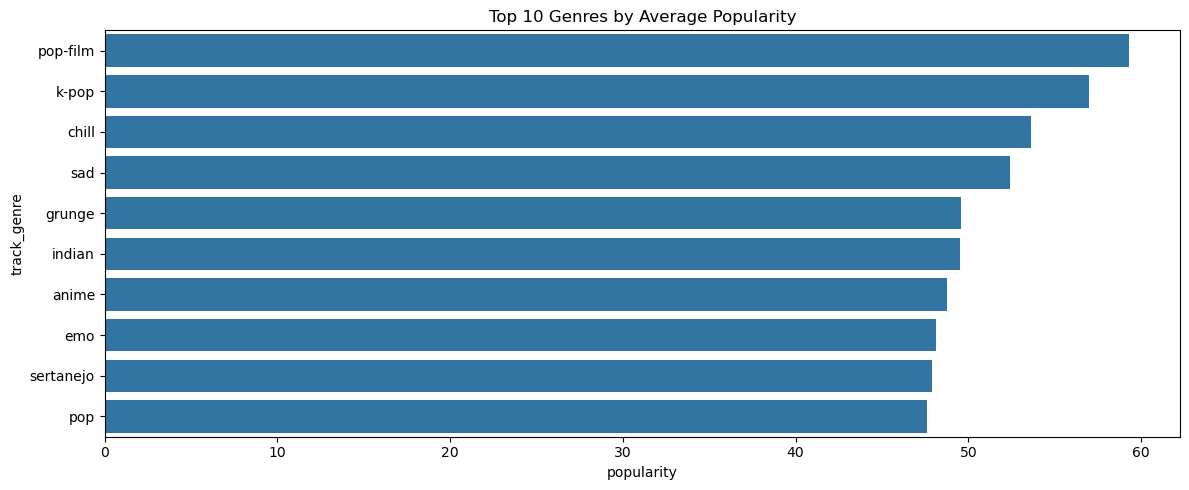

In [4]:
top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_genres, x='popularity', y='track_genre')
plt.title('Top 10 Genres by Average Popularity')
plt.tight_layout()
plt.show()

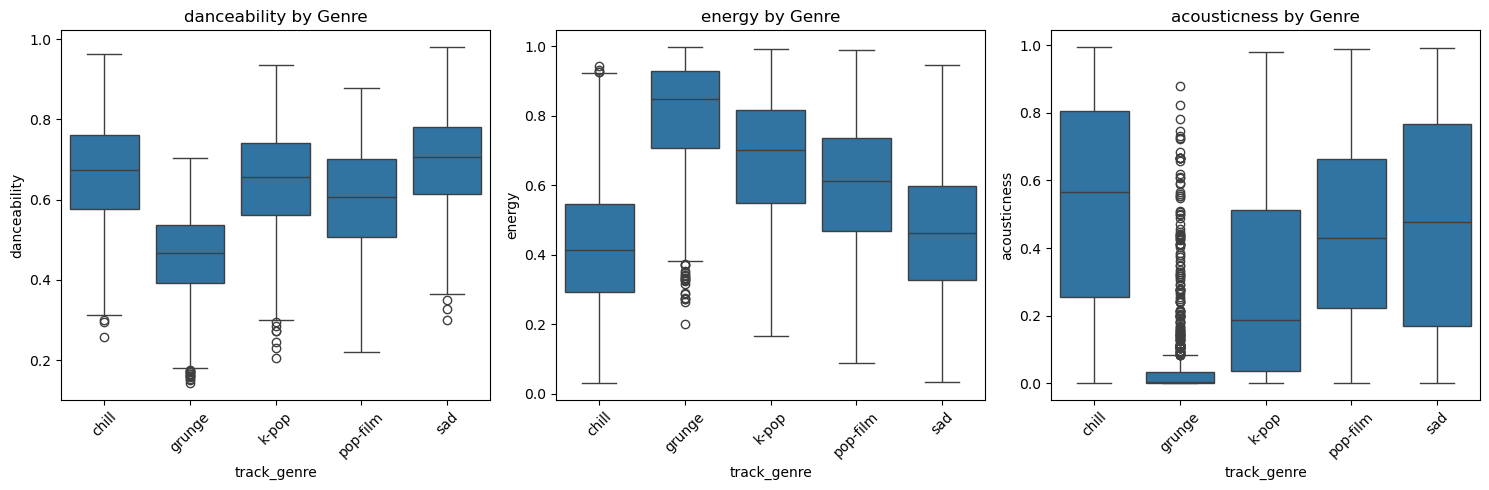

In [5]:
top5_genres = ['pop-film', 'k-pop', 'chill', 'sad', 'grunge']
df_top5 = df[df['track_genre'].isin(top5_genres)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(['danceability', 'energy', 'acousticness']):
    sns.boxplot(data=df_top5, x='track_genre', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by Genre')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

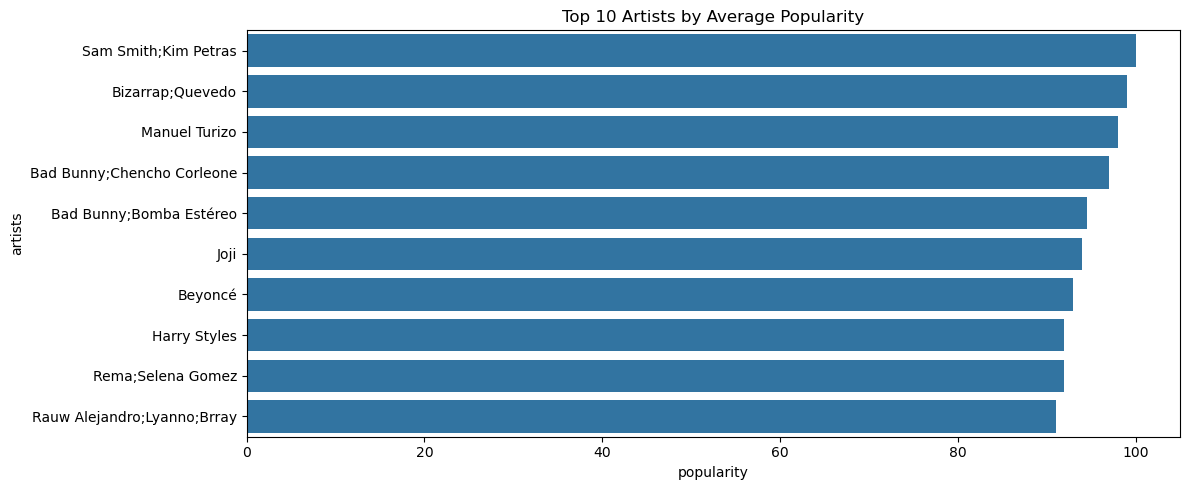

In [6]:
top_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_artists, x='popularity', y='artists')
plt.title('Top 10 Artists by Average Popularity')
plt.tight_layout()
plt.show()

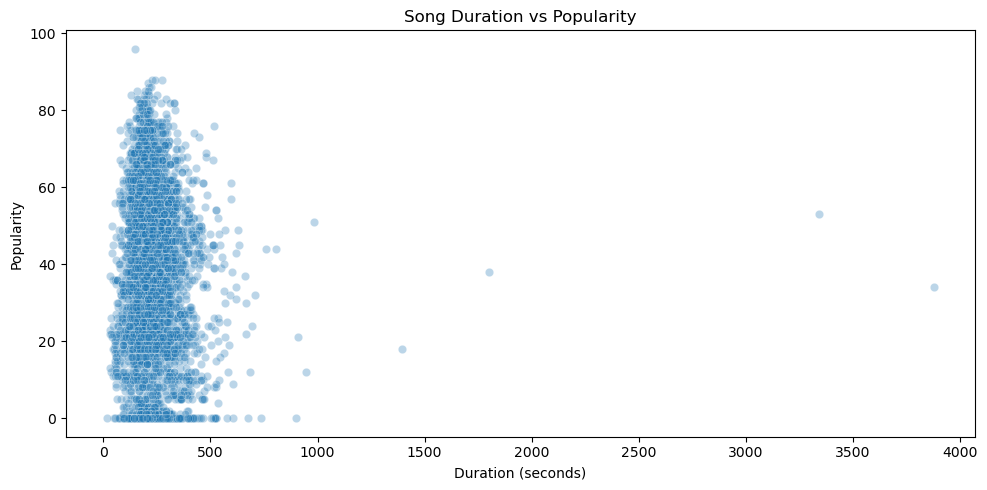

In [7]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(5000), x='duration_sec', y='popularity', alpha=0.3)
plt.title('Song Duration vs Popularity')
plt.xlabel('Duration (seconds)')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

## Key Insights

1. Popularity has NO strong correlation with any single audio feature — marketing and artist fame matter more than sound
2. Pop-film and K-pop are most popular genres — mood and cultural genres beat traditional pop
3. Explicit songs are slightly more popular (36 vs 33 avg) and more danceable
4. Popular songs are louder, more danceable, less acoustic than unpopular ones
5. Grunge = high energy low danceability. Chill = low energy high acousticness. Each genre has a distinct audio fingerprint
6. 18000+ songs have zero popularity — most Spotify songs are never discovered
7. Latin artists dominate top 10 — Bad Bunny, Bizarrap, Manuel Turizo reflect global latin music wave
8. Popular songs are short — all high popularity songs under 500 seconds, sweet spot is 2-5 minutes